In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/placement.csv')

In [5]:
df.head(10)

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
5,5,7.1,48.0,1
6,6,5.7,143.0,0
7,7,5.0,63.0,0
8,8,6.1,156.0,0
9,9,5.1,66.0,0


In [6]:
df.shape

(100, 4)

In [ ]:
# # Steps to perform
# 0. preprocess + eda + feature selection
# 1. extract input and ouput cols
# 2. scale the values
# 3. train test split
# 4. train the model
# 5. evaluate the model and model selection
# 6. deploy the model

In [7]:
# preprocess - if we have missing values / outlier/ columns not needed, we remove them and prepare data to feed algo

# removing the column unnamed
df = df.iloc[:,1:] #All rows but columns are 1 index onwards

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


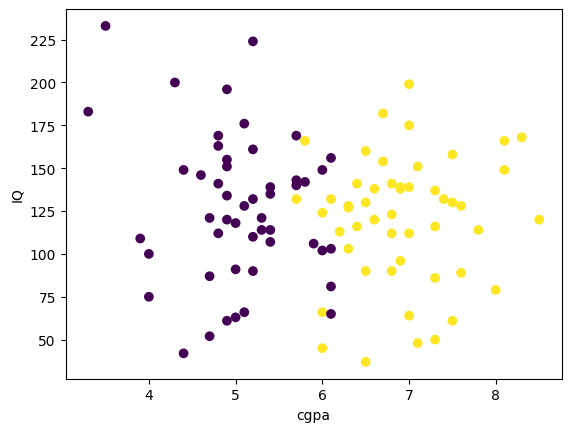

In [16]:
# eda- graph plotting to gain insight from data for predictive modelling

# scatter plot between cgpa and iq
plt.xlabel('cgpa')
plt.ylabel('IQ')
plt.scatter(df.cgpa,df.iq, c=df.placement)

In [21]:
x = df.iloc[:,0:2] # cgpa and iq column
y = df.iloc[:,-1] #placement column

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)


In [23]:
x_train

,cgpa,iq
35,6.8,90.0
11,6.9,138.0
84,5.7,169.0
44,7.5,61.0
73,4.9,61.0
...,...,...
43,6.8,141.0
22,4.9,120.0
72,7.3,116.0
15,5.1,176.0


In [24]:
x_test

,cgpa,iq
83,7.5,130.0
30,7.6,128.0
56,6.1,65.0
24,4.7,121.0
16,5.2,224.0
23,4.7,87.0
2,5.3,121.0
27,6.0,124.0
28,5.2,90.0
13,6.4,116.0


In [25]:
y_train

,placement
35,1
11,1
84,0
44,1
73,0
...,...
43,1
22,0
72,1
15,0


In [26]:
y_test

,placement
83,1
30,1
56,0
24,0
16,0
23,0
2,0
27,1
28,0
13,1


In [28]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [29]:
x_train

array([[ 0.72430457, -0.82086527],
       [ 0.80939174,  0.33545264],
       [-0.21165435,  1.0822413 ],
       [ 1.31991479, -1.51947401],
       [-0.89235174, -1.51947401],
       [ 0.97956609, -1.83264344],
       [-0.80726456, -0.79677531],
       [ 1.14974044, -1.78446353],
       [ 0.6392174 ,  0.72089195],
       [ 0.04360718, -0.53178579],
       [ 1.83043783,  1.00997143],
       [-0.04148   , -0.43542596],
       [-1.65813631, -0.5799657 ],
       [ 0.55413022,  0.33545264],
       [-0.21165435,  0.38363256],
       [ 0.12869435, -1.03767488],
       [-0.21165435,  0.45590243],
       [-0.89235174,  0.64862208],
       [ 1.31991479,  0.81725178],
       [ 0.04360718, -1.90491331],
       [-0.46691587,  0.3595426 ],
       [ 2.00061218,  1.05815134],
       [-0.21165435,  0.19091291],
       [ 0.38395587,  0.40772251],
       [-1.40287478,  1.82902995],
       [ 0.89447892,  0.3595426 ],
       [-0.63709022,  0.19091291],
       [ 0.89447892,  1.80493999],
       [ 0.80939174,

In [30]:
x_test

array([[ 1.31991479e+00,  1.42732992e-01],
       [ 1.40500196e+00,  9.45530794e-02],
       [ 1.28694351e-01, -1.42311418e+00],
       [-1.06252609e+00, -7.40766163e-02],
       [-6.37090216e-01,  2.40718891e+00],
       [-1.06252609e+00, -8.93135138e-01],
       [-5.52003042e-01, -7.40766163e-02],
       [ 4.36071767e-02, -1.80674674e-03],
       [-6.37090216e-01, -8.20865269e-01],
       [ 3.83955873e-01, -1.94526399e-01],
       [ 2.13781525e-01, -2.66796269e-01],
       [-6.37090216e-01, -3.39066138e-01],
       [-8.92351738e-01,  7.44981906e-01],
       [ 1.28694351e-01, -5.07695834e-01],
       [ 7.24304569e-01, -2.58967033e-02],
       [ 9.79566092e-01,  6.48622079e-01],
       [ 1.23482761e+00,  1.90912905e-01],
       [ 8.94478918e-01, -2.90886225e-01],
       [ 1.14974044e+00,  3.11362688e-01],
       [ 4.69043047e-01, -8.20865269e-01]])

In [31]:
#model training- logistic regression classifier
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(x_train,y_train) #used for model training

LogisticRegression()

In [32]:
from sklearn.metrics import accuracy_score
y_pred = clf.predict(x_test)
accuracy_score(y_test,y_pred)

0.9

<Axes: xlabel='cgpa', ylabel='IQ'>

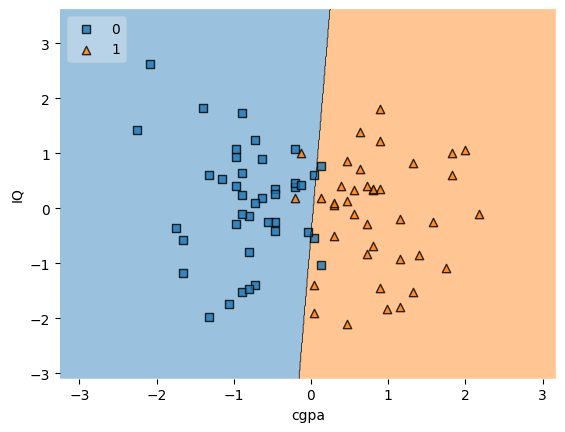

In [40]:
from mlxtend.plotting import plot_decision_regions
plt.xlabel('cgpa')
plt.ylabel('IQ')
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [39]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))
#upload the model.pkl on the website for working
#go on server deployment like heroku or aws or gcp